# Ejercicio 2: Construcción de la variable respuesta

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import OUT_DIR

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

df = pd.read_parquet(OUT_DIR / "ml_dataset.parquet")
print(f"Dataset cargado: {len(df):,} observaciones, {df['lago'].nunique()} lagos, {df['fecha'].nunique()} fechas")
df.head(3)

Dataset cargado: 538,675 observaciones, 2 lagos, 20 fechas


,lago,fecha,x_utm,y_utm,lon,lat,green,red,red_edge,nir,ndvi,ndwi,ndci,cianobacteria
0,atitlan,2025-01-18,697115.0,1631225.0,-91.168902,14.747720,0.0096,0.0012,0.0013,0.0005,-0.411765,0.900990,0.040000,4.601613
1,atitlan,2025-01-18,697215.0,1631225.0,-91.167974,14.747712,0.0132,0.0017,0.0030,0.0111,0.734375,0.086420,0.276596,13.319566
2,atitlan,2025-01-18,697465.0,1631125.0,-91.165660,14.746790,0.0117,0.0031,0.0041,0.0024,-0.127273,0.659574,0.138889,5.521066


### 2.1 Construcción de la variable respuesta binaria

La columna `cianobacteria` calculada en el Ejercicio 1 **no es un índice espectral arbitrario**:
es una estimación de la **concentración de clorofila-a (µg/L)** obtenida a partir del NDCI
mediante el modelo polinómico de **Kravitz et al. (2021)**:

$$\text{Chl-a} = 826.57\,\text{NDCI}^3 - 176.43\,\text{NDCI}^2 + 19\,\text{NDCI} + 4.071$$

Este modelo fue entrenado sobre el dataset sintético LIMNADES (*Lake Bio-optical Measurements
and Matchup Data for Remote Sensing*) mediante simulación de transferencia radiativa (Hydrolight),
calibrado específicamente para floraciones dominadas por *Microcystis aeruginosa*, la cianobacteria
formadora de floraciones tóxicas más común en embalses eutróficos como Amatitlán. Es, de hecho, el
modelo detrás del script público de Sentinel Hub *"Cyanobacteria Chlorophyll-a NDCI L1C"*, la
herramienta a la que hacen referencia las instrucciones del laboratorio.

Como la clorofila-a es el proxy estándar de biomasa fitoplanctónica (incluida la cianobacterial)
usado en monitoreo ambiental, se puede clasificar directamente contra los umbrales de concentración
de clorofila-a definidos en la literatura de salud pública (ver 2.2), en lugar de inventar un
umbral arbitrario sobre el NDCI.

In [ ]:
UMBRAL_ALTA_CIANOBACTERIA = 10.0  # 

df["alta_cianobacteria"] = (df["cianobacteria"] > UMBRAL_ALTA_CIANOBACTERIA).astype(int)

resumen_umbral = df.groupby("alta_cianobacteria")["cianobacteria"].agg(
    n="size", ciano_min="min", ciano_media="mean", ciano_max="max"
)
resumen_umbral.index = resumen_umbral.index.map({0: "0 = ausencia/baja", 1: "1 = alta presencia"})
resumen_umbral

,n,ciano_min,ciano_media,ciano_max
alta_cianobacteria,,,,
0 = ausencia/baja,498997,-19.99173,3.044326,9.996477
1 = alta presencia,39678,10.00234,30.808704,149.939636


### 2.2 Justificación del punto de corte

**Criterio elegido:** `alta_cianobacteria = 1` si la clorofila-a estimada supera **10 µg/L**;
en caso contrario, `0`.

**Justificación científica.** La Organización Mundial de la Salud, en su guía de referencia sobre
cianobacterias tóxicas en agua (Chorus & Bartram, 1999), estableció los niveles de alerta para
aguas recreativas que siguen siendo el estándar más citado en la literatura ambiental y de salud
pública de Latinoamérica (Guatemala no cuenta con un umbral nacional propio, por lo que se recurre
a la referencia internacional):

| Nivel | Densidad celular | Clorofila-a | Probabilidad de efectos adversos |
|---|---|---|---|
| Vigilancia | < 20 000 cél/mL | < 10 µg/L | Baja |
| **Alerta 1** | **≥ 20 000 cél/mL** | **≥ 10 µg/L** | **Moderada** |
| Alerta 2 | ≥ 100 000 cél/mL o espuma visible | ≥ 50 µg/L | Alta |

Se eligió el umbral de **10 µg/L (inicio del Nivel de Alerta 1)** porque:

1. Es el punto donde la OMS considera que el riesgo deja de ser "bajo" y empieza a requerir
   acción de monitoreo activo — es decir, marca el límite operativo entre "condiciones normales"
   y "condiciones que ameritan vigilancia", que es exactamente la distinción que la variable
   respuesta debe capturar (0 = sin necesidad de alerta, 1 = amerita atención).
2. Usar el umbral más alto (50 µg/L, Alerta 2) dejaría muy pocas observaciones en la clase
   positiva (~1.3 % del dataset, ver 2.4), lo que reduciría demasiado la señal disponible para
   entrenar los modelos de los ejercicios 4 en adelante.
3. Es consistente con el marco de 1999 de la OMS, todavía el más usado como referencia operativa
   en estudios de sensores remotos sobre floraciones de cianobacterias en América Latina, y
   comparable en magnitud con los límites de estado trófico de Carlson (1977), donde >7.2 µg/L de
   clorofila-a ya corresponde a condición eutrófica.

**Referencias:**

- Chorus, I., & Bartram, J. (Eds.). (1999). *Toxic Cyanobacteria in Water: A Guide to Their Public
  Health Consequences, Monitoring and Management*. World Health Organization / E & FN Spon.
  https://iris.who.int/handle/10665/42827
- World Health Organization. (2021). *Guidelines on Recreational Water Quality: Volume 1 — Coastal
  and Fresh Waters*. WHO.
- Kravitz, J., Matthews, M., Bernard, S., & Griffith, D. (2021). Potential for high fidelity global
  mapping of common inland water quality products at high spatial and temporal resolutions based
  on a synthetic data and machine learning approach. *Frontiers in Environmental Science, 9*,
  587660. https://doi.org/10.3389/fenvs.2021.587660
- Mishra, S., & Mishra, D. R. (2012). Normalized difference chlorophyll index: A novel model for
  remote estimation of chlorophyll-a concentration in turbid productive waters. *Remote Sensing of
  Environment, 117*, 394–406. https://doi.org/10.1016/j.rse.2011.10.016
- Carlson, R. E. (1977). A trophic state index for lakes. *Limnology and Oceanography, 22*(2),
  361–369.
- Sentinel Hub. *Cyanobacteria Chlorophyll-a NDCI L1C* [Custom script documentation].
  https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/cyanobacteria_chla_ndci_l1c/

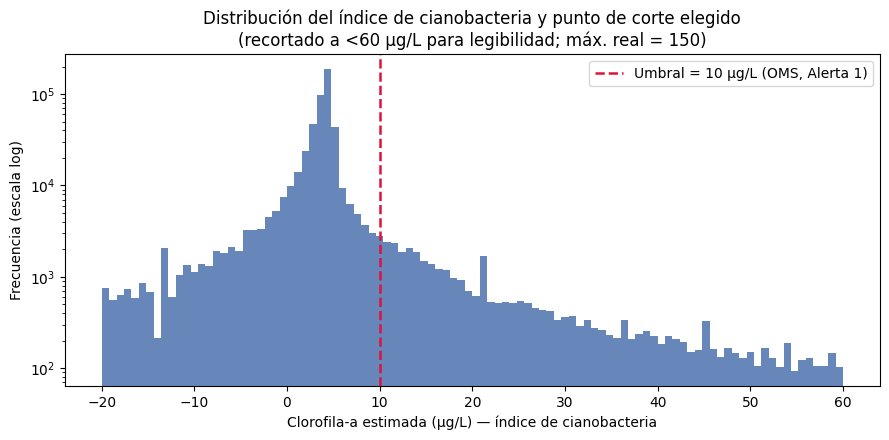

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(df.loc[df["cianobacteria"] < 60, "cianobacteria"], bins=100, color="#4c72b0", alpha=0.85)
ax.axvline(UMBRAL_ALTA_CIANOBACTERIA, color="crimson", linestyle="--", linewidth=1.8,
           label=f"Umbral = {UMBRAL_ALTA_CIANOBACTERIA:.0f} µg/L (OMS, Alerta 1)")
ax.set_yscale("log")
ax.set_xlabel("Clorofila-a estimada (µg/L) — índice de cianobacteria")
ax.set_ylabel("Frecuencia (escala log)")
ax.set_title("Distribución del índice de cianobacteria y punto de corte elegido\n(recortado a <60 µg/L para legibilidad; máx. real = {:.0f})".format(df["cianobacteria"].max()))
ax.legend()
plt.tight_layout()
plt.show()

### 2.3 Distribución de la variable respuesta

In [4]:
print("Distribución global de la variable respuesta:")
dist_global = df["alta_cianobacteria"].value_counts().rename("n").to_frame()
dist_global["pct"] = (dist_global["n"] / len(df) * 100).round(2)
dist_global.index = dist_global.index.map({0: "0 = ausencia/baja", 1: "1 = alta presencia"})
dist_global

Distribución global de la variable respuesta:


,n,pct
alta_cianobacteria,,
0 = ausencia/baja,498997,92.63
1 = alta presencia,39678,7.37


In [5]:
dist_lago = (
    df.groupby("lago", observed=True)["alta_cianobacteria"]
      .agg(n_total="size", n_alta="sum")
      .assign(pct_alta=lambda t: (t["n_alta"] / t["n_total"] * 100).round(2))
)
print("Distribución de la variable respuesta por lago:")
dist_lago

Distribución de la variable respuesta por lago:


,n_total,n_alta,pct_alta
lago,,,
amatitlan,65233,29182,44.74
atitlan,473442,10496,2.22


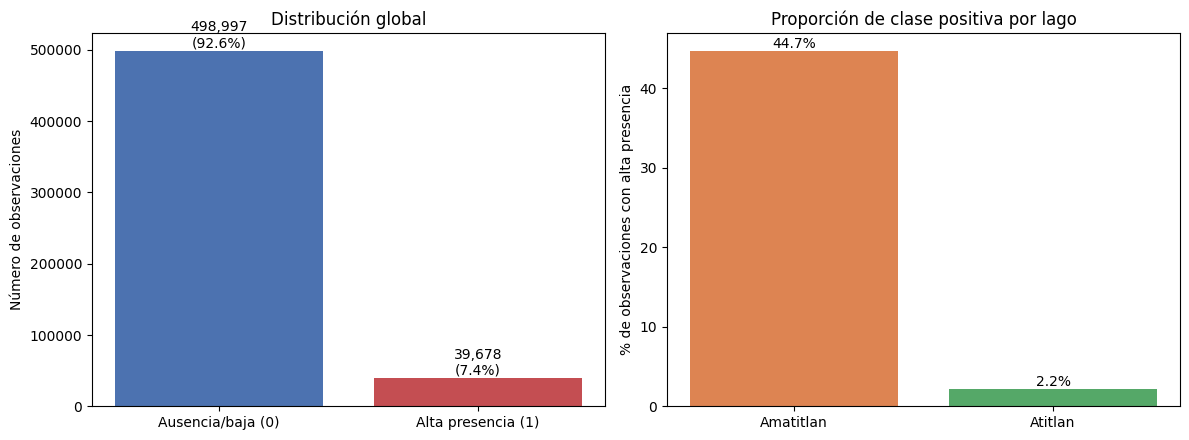

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(["Ausencia/baja (0)", "Alta presencia (1)"], dist_global["n"],
            color=["#4c72b0", "#c44e52"])
axes[0].set_title("Distribución global")
axes[0].set_ylabel("Número de observaciones")
for i, v in enumerate(dist_global["n"]):
    axes[0].text(i, v, f"{v:,}\n({dist_global['pct'].iloc[i]:.1f}%)", ha="center", va="bottom")

x = np.arange(len(dist_lago))
axes[1].bar(x, dist_lago["pct_alta"], color=["#dd8452", "#55a868"])
axes[1].set_xticks(x)
axes[1].set_xticklabels([l.capitalize() for l in dist_lago.index])
axes[1].set_ylabel("% de observaciones con alta presencia")
axes[1].set_title("Proporción de clase positiva por lago")
for i, v in enumerate(dist_lago["pct_alta"]):
    axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

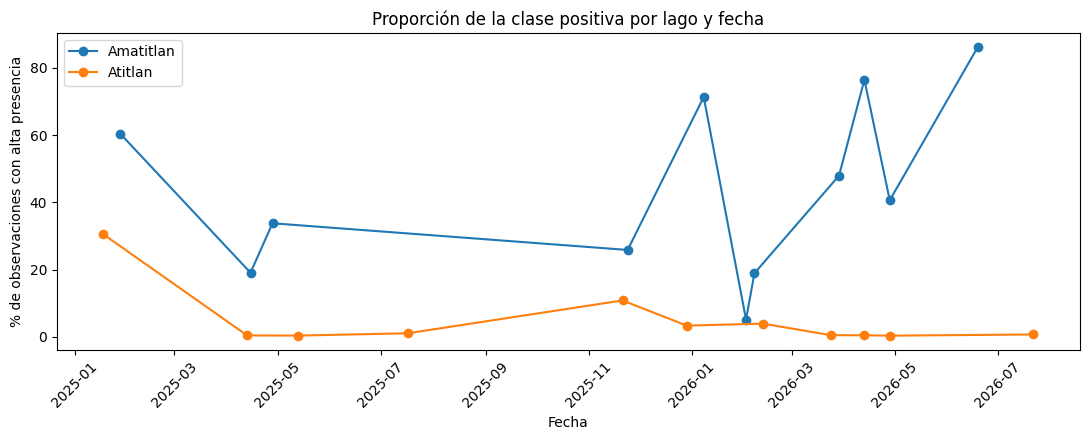

,lago,fecha,n,n_alta,pct_alta
0,amatitlan,2025-01-28,6129,3702,60.40
1,amatitlan,2025-04-15,6088,1162,19.09
2,amatitlan,2025-04-28,5933,2005,33.79
3,amatitlan,2025-11-24,6016,1556,25.86
4,amatitlan,2026-01-08,5680,4052,71.34
5,amatitlan,2026-02-02,5595,289,5.17
6,amatitlan,2026-02-07,5714,1083,18.95
7,amatitlan,2026-03-29,6241,2993,47.96
8,amatitlan,2026-04-13,6296,4814,76.46
9,amatitlan,2026-04-28,5304,2155,40.63


In [7]:
tabla_temporal = (
    df.groupby(["lago", "fecha"], observed=True)["alta_cianobacteria"]
      .agg(n="size", n_alta="sum")
      .assign(pct_alta=lambda t: (t["n_alta"] / t["n"] * 100).round(2))
      .reset_index()
      .sort_values(["lago", "fecha"])
)

fig, ax = plt.subplots(figsize=(11, 4.5))
for lago, grupo in tabla_temporal.groupby("lago", observed=True):
    ax.plot(grupo["fecha"], grupo["pct_alta"], marker="o", label=lago.capitalize())
ax.set_xlabel("Fecha")
ax.set_ylabel("% de observaciones con alta presencia")
ax.set_title("Proporción de la clase positiva por lago y fecha")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

tabla_temporal

**Lectura de los resultados.** La variable respuesta está fuertemente concentrada en Amatitlán:
mientras que en Atitlán la proporción de observaciones con alta presencia de cianobacteria ronda
apenas el 2 %, en Amatitlán supera el 40 %, consistente con la condición hipereutrófica bien
documentada de ese lago frente al estado más oligo-mesotrófico de Atitlán. A nivel temporal, ambos
lagos muestran variación marcada entre fechas — en Amatitlán la proporción de clase positiva oscila
entre ~5 % y ~86 % según la escena, y en Atitlán la mayoría de fechas está por debajo del 1 %, con
un par de fechas (2025-01-18 y 2025-11-21) que concentran eventos de floración notablemente más
altos que el resto. Esto sugiere que la fecha de adquisición (y probablemente la estacionalidad que
representa) es una fuente importante de variabilidad que los modelos deberán poder capturar.

### 2.4 Desbalance entre clases

In [8]:
n0, n1 = dist_global["n"]
print(f"Razón de desbalance global (clase 0 : clase 1) = {n0/n1:.1f} : 1")
print(f"Proporción de la clase minoritaria (alta presencia): {n1/len(df)*100:.2f}%\n")

for lago, fila in dist_lago.iterrows():
    n_total, n_alta = int(fila["n_total"]), int(fila["n_alta"])
    razon = (n_total - n_alta) / n_alta
    print(f"{lago.capitalize():>10}: razón 0:1 = {razon:5.1f} : 1  "
          f"({n_alta:,} positivas de {n_total:,})")

Razón de desbalance global (clase 0 : clase 1) = 12.6 : 1
Proporción de la clase minoritaria (alta presencia): 7.37%

 Amatitlan: razón 0:1 =   1.2 : 1  (29,182 positivas de 65,233)
   Atitlan: razón 0:1 =  44.1 : 1  (10,496 positivas de 473,442)


**¿Existe desbalance?** Sí, y es sustancial: a nivel global la clase 0 supera a la clase 1 en una
razón cercana a 12:1 (~7 % de observaciones positivas). El desbalance, además, es muy distinto
entre lagos — extremo en Atitlán (~44:1) y moderado en Amatitlán (~1.2:1) — por lo que un modelo
entrenado con ambos lagos mezclados estará dominado por el comportamiento de Atitlán simplemente
porque aporta la gran mayoría de las filas (473 442 de 538 675).

**Consecuencias para el entrenamiento y la evaluación:**

- **Sesgo hacia la clase mayoritaria:** los algoritmos que optimizan una pérdida agregada (como la
  log-verosimilitud en regresión logística, o el Gini/entropía en árboles) pueden alcanzar un error
  bajo simplemente prediciendo casi siempre "0", sin aprender a distinguir realmente los casos de
  alta presencia.
- **Accuracy engañosa:** con ~93 % de la clase mayoritaria, un modelo trivial que siempre prediga 0
  obtendría ~93 % de exactitud sin ningún valor práctico. Esto obliga a usar métricas sensibles a la
  clase minoritaria (Recall, F1, ROC-AUC/PR-AUC) en lugar de exactitud, como se discute en el
  Ejercicio 5.
- **Recall reducido en la clase de interés:** desde el punto de vista ambiental, la clase 1 (alta
  presencia) es la que realmente importa detectar; un modelo desbalanceado tiende a tener recall
  bajo precisamente en esa clase, es decir, a "dejar pasar" floraciones reales — el error más costoso
  en este contexto (ver Ejercicio 5.3).
- **Necesidad de particiones estratificadas:** al dividir entrenamiento/prueba (Ejercicio 4) y al
  construir los bloques espaciales (Ejercicio 6), debe verificarse que ambas clases estén
  representadas en cada partición; de lo contrario algunos bloques o folds podrían quedar sin
  ningún ejemplo positivo.
- **Heterogeneidad entre lagos:** dado que Amatitlán está mucho más balanceado que Atitlán, el
  desempeño de un mismo modelo puede variar fuertemente según el lago evaluado — un punto central
  para interpretar los resultados de generalización entre lagos del Ejercicio 7.
- Se documenta el desbalance aquí; el tratamiento (p. ej. `class_weight="balanced"`, ponderación en
  Gradient Boosting/XGBoost, o ajuste del umbral de decisión) se aplicará al construir los modelos
  en el Ejercicio 4, sin recurrir a sobremuestreo/submuestreo que alteraría la estructura espacial
  de las observaciones.

### 2.5 Variables que no pueden utilizarse como predictoras (fuga de información)

In [9]:
# Cadena de construcción de la variable respuesta:
#   red, red_edge  -->  ndci = (red_edge - red) / (red_edge + red)
#   ndci           -->  cianobacteria = f(ndci)   [polinomio de Kravitz et al., 2021]
#   cianobacteria  -->  alta_cianobacteria = 1[cianobacteria > 10]

variables_excluidas = ["red", "red_edge", "ndci", "cianobacteria"]
print("Variables excluidas como predictoras (usadas directa o indirectamente en la respuesta):")
for v in variables_excluidas:
    print(" -", v)

Variables excluidas como predictoras (usadas directa o indirectamente en la respuesta):
 - red
 - red_edge
 - ndci
 - cianobacteria


In [10]:
cols_candidatas = ["green", "red", "red_edge", "nir", "ndvi", "ndwi", "ndci", "cianobacteria"]
corr_con_respuesta = df[cols_candidatas].corr()[["ndci", "cianobacteria"]].round(3)
corr_con_respuesta

,ndci,cianobacteria
green,0.014,0.008
red,-0.001,-0.007
red_edge,0.038,0.028
nir,0.003,-0.002
ndvi,0.217,0.214
ndwi,-0.097,-0.078
ndci,1.000,0.802
cianobacteria,0.802,1.000


**¿Por qué se excluyen exactamente esas variables?**

- `red` y `red_edge` son las bandas crudas con las que se calcula `ndci`
  (`ndci = (red_edge − red) / (red_edge + red)`); a pesar de tener correlación individual casi nula
  con `cianobacteria` (ver tabla, |r| < 0.04), forman parte literal de la fórmula de la variable
  respuesta y deben excluirse por construcción, no por su correlación observada.
- `ndci` tiene correlación 0.80 con `cianobacteria` porque es su insumo directo en el polinomio de
  Kravitz et al. (2021); usarla como predictora sería equivalente a filtrar la respuesta misma.
- `cianobacteria` es la variable continua de la que se derivó `alta_cianobacteria`; obviamente no
  puede usarse como predictora.

**¿Por qué NO se excluyen `green`, `nir`, `ndvi` y `ndwi`?**

Aunque `ndvi = (nir − red) / (nir + red)` reutiliza la banda `red`, su fórmula no incluye
`red_edge` ni depende de `ndci`/`cianobacteria`: la correlación de `ndvi` con la respuesta es
moderada (r ≈ 0.21) y refleja una relación biológica real y esperable — el NDVI también responde a
la presencia de biomasa fotosintética (incluyendo acumulaciones algales) en la superficie del agua,
no una fuga algebraica de la fórmula de cianobacteria. De hecho, `red` por sí sola —el componente
que `ndvi` comparte con `ndci`— tiene correlación prácticamente nula con `cianobacteria` (r ≈ −0.007),
lo que confirma que la señal de `ndvi` no proviene de esa banda compartida. `green`, `nir` y `ndwi`
no intervienen en ningún paso de la fórmula de la respuesta. Estas cuatro variables se mantienen
como candidatas legítimas para el conjunto de predictores del Ejercicio 3.

In [11]:
predictoras_candidatas = ["green", "nir", "ndvi", "ndwi", "lon", "lat", "x_utm", "y_utm", "fecha", "lago"]
no_predictoras = ["red", "red_edge", "ndci", "cianobacteria"]

print("Conservadas como candidatas a predictoras:", predictoras_candidatas)
print("Excluidas por fuga de información:        ", no_predictoras)

Conservadas como candidatas a predictoras: ['green', 'nir', 'ndvi', 'ndwi', 'lon', 'lat', 'x_utm', 'y_utm', 'fecha', 'lago']
Excluidas por fuga de información:         ['red', 'red_edge', 'ndci', 'cianobacteria']


Se guarda el dataset con la variable respuesta ya construida para reutilizarlo en los
ejercicios siguientes (selección de predictoras, modelado, validación espacial, etc.).

In [12]:
out_path = OUT_DIR / "ml_dataset_respuesta.parquet"
df.to_parquet(out_path, index=False)
print(f"Dataset con variable respuesta guardado en {out_path} ({len(df):,} filas, {df.shape[1]} columnas)")

Dataset con variable respuesta guardado en C:\Users\sofia\Documents\DataScience\Lab4.2-DataScience\data\processed\ml_dataset_respuesta.parquet (538,675 filas, 15 columnas)
